In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Download NLTK Resources
Description

Download stopwords and tokenizer resources used in NLP preprocessing.

In [47]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\Bidisha
[nltk_data]     Shit\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Bidisha
[nltk_data]     Shit\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load the fake news dataset.

In [48]:
import pandas as pd

fake_df = pd.read_csv('Fake.csv')
true_df = pd.read_csv('True.csv')

print(fake_df.head())
print(true_df.head())

fake_df['label'] = 0
true_df['label'] = 1

C:\Users\Bidisha Shit\AppData\Local\Temp\ipykernel_18512\2324664987.py:3: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171) have mixed types. Specify dtype option on import or set low_memory=False.
  fake_df = pd.read_csv('Fake.csv')


                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date Unnamed: 4 Unnamed: 5 Unnamed: 6 Unnamed: 7 Unnamed: 8  \
0  December 31, 2017        NaN        NaN        NaN        NaN        NaN   
1  December 31, 2017        NaN        NaN        NaN        NaN        NaN   
2  December 30, 2017        NaN        Na

merge dataset

In [49]:
df = pd.concat([fake_df, true_df], axis=0)

print(df.shape)

(44939, 173)


In [50]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

Remove rows with missing text or labels.

In [51]:
print(df.isnull().sum())

# Remove missing rows

df.dropna(inplace=True)

print(df.shape)

title      20
text       20
subject    41
date       41
label       0
dtype: int64
(44898, 5)


In [52]:
#Shuffle Dataset

In [53]:
df = df.sample(frac=1, random_state=42)

df.reset_index(drop=True, inplace=True)

In [54]:
#Combine Title and Text

In [55]:
df['content'] = df['title'] + " " + df['text']

Convert text labels (FAKE/REAL) into numeric values.
FAKE → 0
REAL → 1

In [ ]:
encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['label'])

print(df['label'].value_counts())
#print(encoder.classes_)

label
0    23481
1    21417
Name: count, dtype: int64
[0 1]


NLP Text Preprocessing
Description

Clean and preprocess text using:

Lowercasing
Removing special characters
Tokenization
Stopword removal
Stemming

In [57]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))


def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = word_tokenize(text)

    # Remove stopwords and stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return ' '.join(words)


# Apply preprocessing

df['clean_content'] = df['content'].apply(preprocess_text)

print(df[['text', 'clean_content']].head())

                                                text  \
0  21st Century Wire says Ben Stein, reputable pr...   
1  WASHINGTON (Reuters) - U.S. President Donald T...   
2  (Reuters) - Puerto Rico Governor Ricardo Rosse...   
3  On Monday, Donald Trump once again embarrassed...   
4  GLASGOW, Scotland (Reuters) - Most U.S. presid...   

                                       clean_content  
0  ben stein call th circuit court commit coup ta...  
1  trump drop steve bannon nation secur council w...  
2  puerto rico expect u lift jone act ship restri...  
3  oop trump accident confirm leak isra intellig ...  
4  donald trump head scotland reopen golf resort ...  


Split Features and Labels
Separate input text and target labels.

In [58]:
X = df['clean_content']
y = df['label']

Train-Test Split
Split dataset into training and testing sets.

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(35918,)
(8980,)


Tokenization and Text Sequencing
Convert text into numeric sequences for deep learning.

In [60]:
# Maximum vocabulary size
vocab_size = 10000

# Maximum sentence length
max_length = 300

# Tokenizer

tokenizer = Tokenizer(num_words=vocab_size)

tokenizer.fit_on_texts(X_train)

# Convert text to sequences

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=max_length)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length)

print(X_train_pad.shape)

(35918, 300)


Build Deep Learning Model
Create an LSTM-based neural network.
Model architecture:
Embedding Layer
LSTM Layer
Dropout Layer
Dense Output Layer

In [61]:
model = Sequential()

model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_shape=(max_length,)
    )
)

model.add(LSTM(128))
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

C:\Users\Bidisha Shit\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 300, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

Add Early Stopping
Stop training automatically if validation loss stops improving.

In [62]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

Train the LSTM model on training data.

In [63]:
history = model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 116s 252ms/step - accuracy: 0.9566 - loss: 0.1206 - val_accuracy: 0.9830 - val_loss: 0.0580
Epoch 2/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 240ms/step - accuracy: 0.9868 - loss: 0.0463 - val_accuracy: 0.9839 - val_loss: 0.0539
Epoch 3/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 240ms/step - accuracy: 0.9833 - loss: 0.0514 - val_accuracy: 0.9833 - val_loss: 0.0621
Epoch 4/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 102s 226ms/step - accuracy: 0.9927 - loss: 0.0248 - val_accuracy: 0.9871 - val_loss: 0.0486
Epoch 5/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 107s 239ms/step - accuracy: 0.9944 - loss: 0.0204 - val_accuracy: 0.9872 - val_loss: 0.0530
Epoch 6/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 107s 239ms/step - accuracy: 0.9859 - loss: 0.0469 - val_accuracy: 0.9773 - val_loss: 0.0749
Epoch 7/10
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 241ms/step - accuracy: 0.9958 - loss: 0.0145 - val_accuracy: 0.9832 - val_loss: 0.0695


Evaluate Model
Check model performance on test data.

In [64]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

281/281 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.9860 - loss: 0.0499
Test Loss: 0.04991389065980911
Test Accuracy: 0.985968828201294


Predict fake or real news.

In [65]:
predictions = model.predict(X_test_pad)

# Convert probabilities to classes
pred_classes = (predictions > 0.5).astype(int)

281/281 ━━━━━━━━━━━━━━━━━━━━ 12s 42ms/step


Classification Report
Display precision, recall, and F1-score.

In [66]:
print(classification_report(y_test, pred_classes))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4696
           1       0.98      0.99      0.99      4284

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



Confusion Matrix
Visualize prediction performance.

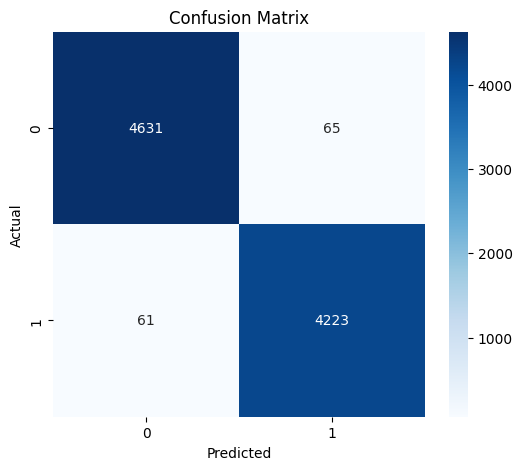

In [67]:
cm = confusion_matrix(y_test, pred_classes)

plt.figure(figsize=(6, 5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

Save trained model for future use.

In [68]:
model.save('fake_news_model.h5')

print("Model saved successfully")

Model saved successfully


Load the trained model later without retraining.

In [69]:
from tensorflow.keras.models import load_model

loaded_model = load_model('fake_news_model.h5')

print("Model loaded successfully")

Model loaded successfully


Use the trained model to classify custom news.

In [ ]:
sample_news = "Aliens officially elected a cat as president of the Moon."

# Preprocess
clean_news = preprocess_text(sample_news)

# Convert to sequence
sequence = tokenizer.texts_to_sequences([clean_news])

# Padding
padded = pad_sequences(sequence, maxlen=max_length)

# Prediction
prediction = model.predict(padded)

if prediction[0][0] > 0.5:
    print("REAL News")
else:
    print("FAKE News")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
FAKE News
